In [2]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 48.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=5b23983a943bdedfe49f56d3c54206ace120700f22aae014b4f66ce510c7ecd8
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [3]:
import os, random, warnings, zipfile
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms.functional as TF
import timm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
from scipy.ndimage import gaussian_filter, rotate as scipy_rotate
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from google.colab import drive

In [4]:
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [6]:
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
DATASET_ZIP   = '/content/drive/MyDrive/Deeplense/CT/dataset.zip'
CHECKPOINT_DIR = '/content/drive/MyDrive/Deeplense/RobustnessTesting/deeplense_checkpoints'

In [8]:
EXTRACT_DIR = '/content/dataset_extracted'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

In [9]:
with zipfile.ZipFile(DATASET_ZIP, 'r') as z:
    z.extractall(EXTRACT_DIR)

TRAIN_DIR = os.path.join(EXTRACT_DIR, 'dataset', 'train')
TEST_DIR  = os.path.join(EXTRACT_DIR, 'dataset', 'val')

In [10]:
CLASS_NAMES  = ['no', 'sphere', 'vort']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

print("Classes:", CLASS_NAMES)
for split, d in [('train', TRAIN_DIR), ('test', TEST_DIR)]:
    counts = {c: len(os.listdir(os.path.join(d, c))) for c in CLASS_NAMES}
    print(f"  {split}: {counts}")

Classes: ['no', 'sphere', 'vort']
  train: {'no': 10000, 'sphere': 10000, 'vort': 10000}
  test: {'no': 2500, 'sphere': 2500, 'vort': 2500}


In [11]:
class LensingDataset(Dataset):

    def __init__(self, root_dir, augment=False):
        self.augment = augment
        self.samples = []
        for cls in CLASS_NAMES:
            cls_dir = os.path.join(root_dir, cls)
            for fname in os.listdir(cls_dir):
                if fname.endswith('.npy'):
                    self.samples.append((
                        os.path.join(cls_dir, fname),
                        CLASS_TO_IDX[cls]
                    ))

    def __len__(self):
        return len(self.samples)

    @staticmethod
    def normalize(img_np):
        t = torch.tensor(img_np, dtype=torch.float32)
        return (t - 0.5) / 0.5

    @staticmethod
    def augment_tensor(t):
        # Random horizontal / vertical flip
        if random.random() > 0.5:
            t = TF.hflip(t)
        if random.random() > 0.5:
            t = TF.vflip(t)
        # Random 90° rotation (lensing images are rotationally symmetric)
        angle = random.choice([0, 90, 180, 270])
        t = TF.rotate(t, angle)
        # Mild Gaussian noise (σ sampled uniformly)
        if random.random() > 0.5:
            sigma = random.uniform(0.01, 0.05)
            t = t + torch.randn_like(t) * sigma
        # Mild Gaussian blur (scipy on numpy for speed)
        if random.random() > 0.4:
            arr = t.numpy()
            sigma_b = random.uniform(0.3, 1.0)
            arr = gaussian_filter(arr, sigma=[0, sigma_b, sigma_b])
            t = torch.tensor(arr)
        return t

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = np.load(path).astype(np.float32)   # (1, 150, 150)
        t = self.normalize(img)
        if self.augment:
            t = self.augment_tensor(t)
        return t, label

In [12]:
BATCH_SIZE  = 32
NUM_WORKERS = 2
VAL_FRAC    = 0.15

train_clean_ds  = LensingDataset(TRAIN_DIR, augment=False)
train_aug_ds    = LensingDataset(TRAIN_DIR, augment=True)
test_ds         = LensingDataset(TEST_DIR,  augment=False)

def split_dataset(ds, val_frac=VAL_FRAC):
    n_val   = int(len(ds) * val_frac)
    n_train = len(ds) - n_val
    return random_split(ds, [n_train, n_val],
                        generator=torch.Generator().manual_seed(SEED))

train_clean_ds, val_clean_ds = split_dataset(train_clean_ds)
train_aug_ds,   val_aug_ds   = split_dataset(train_aug_ds)

train_clean_loader = DataLoader(train_clean_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
train_aug_loader   = DataLoader(train_aug_ds,   batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_clean_loader   = DataLoader(val_clean_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
val_aug_loader     = DataLoader(val_aug_ds,     batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader        = DataLoader(test_ds,        batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train clean: {len(train_clean_ds)} | Val: {len(val_clean_ds)} | Test: {len(test_ds)}")

Train clean: 25500 | Val: 4500 | Test: 7500


In [13]:
def build_densenet121():
    model = timm.create_model(
        'densenet121',
        pretrained=True,
        in_chans=1,
        num_classes=3
    )
    for param in model.parameters():
        param.requires_grad = True
    return model.to(device)

In [14]:
_m = build_densenet121()
_x = torch.randn(2, 1, 150, 150).to(device)
print("Output shape:", _m(_x).shape)   # expect (2, 3)
del _m, _x

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

Output shape: torch.Size([2, 3])


In [15]:
def evaluate(model, loader, return_all=False):
    """Macro OvR AUC on clean data."""
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            probs = torch.softmax(model(imgs), dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())
    P = np.concatenate(all_probs)
    Y = np.concatenate(all_labels)
    macro_auc = roc_auc_score(Y, P, multi_class='ovr', average='macro')
    if return_all:
        per_class = roc_auc_score(
            label_binarize(Y, classes=[0,1,2]), P,
            average=None
        )
        return macro_auc, per_class, P, Y
    return macro_auc

In [16]:
def evaluate_corrupted(model, corrupt_fn, loader):
    """
    corrupt_fn operates on numpy arrays of shape (B, 1, H, W) in [0,1].
    Images are denormed → corrupted → re-normed before inference.
    """
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            # denorm to [0,1]
            imgs_np = (imgs.numpy() * 0.5 + 0.5)
            imgs_np = corrupt_fn(imgs_np)
            imgs_np = np.clip(imgs_np, 0.0, 1.0)
            # re-norm to [-1,1]
            imgs_t = torch.tensor(
                (imgs_np - 0.5) / 0.5, dtype=torch.float32
            ).to(device)
            probs = torch.softmax(model(imgs_t), dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())
    P = np.concatenate(all_probs)
    Y = np.concatenate(all_labels)
    return roc_auc_score(Y, P, multi_class='ovr', average='macro')

In [17]:
def train_model(train_loader, val_loader, name, epochs=15):

    model     = build_densenet121()
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    criterion = nn.CrossEntropyLoss()
    ckpt_path = os.path.join(CHECKPOINT_DIR, f'{name}_best.pth')

    best_auc  = 0.0
    history   = {'train_loss': [], 'val_auc': [], 'per_class_auc': []}

    for epoch in range(1, epochs + 1):
        # ── Train ────────────────────────────────────────────────────────────
        model.train()
        running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        scheduler.step()

        # ── Eval ─────────────────────────────────────────────────────────────
        macro_auc, per_class, _, _ = evaluate(model, val_loader, return_all=True)
        avg_loss = running_loss / len(train_loader)

        history['train_loss'].append(avg_loss)
        history['val_auc'].append(macro_auc)
        history['per_class_auc'].append(per_class.tolist())

        if macro_auc > best_auc:
            best_auc = macro_auc
            torch.save(model.state_dict(), ckpt_path)

        pc = ' | '.join(f'{CLASS_NAMES[i]}: {per_class[i]:.4f}' for i in range(3))
        print(f"[{name}] Ep {epoch:02d}/{epochs} | "
              f"Loss: {avg_loss:.4f} | AUC: {macro_auc:.4f} | Best: {best_auc:.4f}")
        print(f"         Per-class AUC → {pc}")

    print(f"\n✓ {name} done. Best macro AUC: {best_auc:.4f}")
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    return model, history

In [18]:
EPOCHS = 15

print("=" * 60)
print("MODEL A — Clean Training")
print("=" * 60)
model_clean, hist_clean = train_model(train_clean_loader, val_clean_loader, 'model_clean', epochs=EPOCHS)

print("\n" + "=" * 60)
print("MODEL B — Augmented Training")
print("=" * 60)
model_aug,   hist_aug   = train_model(train_aug_loader,   val_aug_loader,   'model_aug',   epochs=EPOCHS)

MODEL A — Clean Training


[model_clean] Ep 01/15 | Loss: 1.0848 | AUC: 0.7153 | Best: 0.7153
         Per-class AUC → no: 0.8053 | sphere: 0.6702 | vort: 0.6704
[model_clean] Ep 02/15 | Loss: 0.6940 | AUC: 0.9261 | Best: 0.9261
         Per-class AUC → no: 0.9513 | sphere: 0.9014 | vort: 0.9255
[model_clean] Ep 03/15 | Loss: 0.4197 | AUC: 0.9570 | Best: 0.9570
         Per-class AUC → no: 0.9707 | sphere: 0.9404 | vort: 0.9598
[model_clean] Ep 04/15 | Loss: 0.3029 | AUC: 0.9673 | Best: 0.9673
         Per-class AUC → no: 0.9770 | sphere: 0.9545 | vort: 0.9704
[model_clean] Ep 05/15 | Loss: 0.2294 | AUC: 0.9665 | Best: 0.9673
         Per-class AUC → no: 0.9784 | sphere: 0.9500 | vort: 0.9712
[model_clean] Ep 06/15 | Loss: 0.1748 | AUC: 0.9725 | Best: 0.9725
         Per-class AUC → no: 0.9799 | sphere: 0.9627 | vort: 0.9748
[model_clean] Ep 07/15 | Loss: 0.1283 | AUC: 0.9764 | Best: 0.9764
         Per-class AUC → no: 0.9833 | sphere: 0.9655 | vort: 0.9805
[model_clean] Ep 08/15 | Loss: 0.0839 | AUC: 0.9744 | B

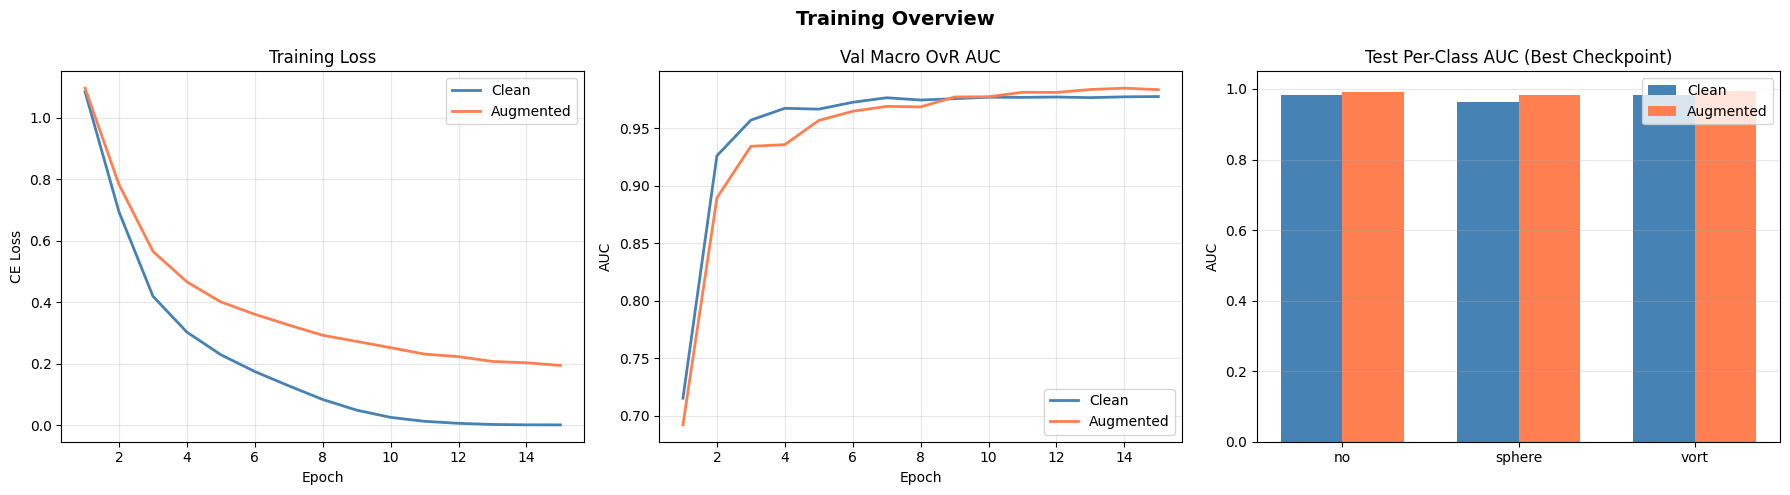

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_x = list(range(1, EPOCHS + 1))
colors   = {'Clean': 'steelblue', 'Aug': 'coral'}

# Loss
axes[0].plot(epochs_x, hist_clean['train_loss'], color=colors['Clean'], label='Clean', lw=2)
axes[0].plot(epochs_x, hist_aug['train_loss'],   color=colors['Aug'],   label='Augmented', lw=2)
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('CE Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Val AUC curve
axes[1].plot(epochs_x, hist_clean['val_auc'], color=colors['Clean'], label='Clean', lw=2)
axes[1].plot(epochs_x, hist_aug['val_auc'],   color=colors['Aug'],   label='Augmented', lw=2)
axes[1].set_title('Val Macro OvR AUC'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC'); axes[1].legend(); axes[1].grid(alpha=0.3)

# Test per-class AUC bar chart
_, clean_pc, _, _ = evaluate(model_clean, test_loader, return_all=True)
_, aug_pc,   _, _ = evaluate(model_aug,   test_loader, return_all=True)
x = np.arange(len(CLASS_NAMES)); w = 0.35
axes[2].bar(x - w/2, clean_pc, w, label='Clean',     color=colors['Clean'])
axes[2].bar(x + w/2, aug_pc,   w, label='Augmented', color=colors['Aug'])
axes[2].set_xticks(x); axes[2].set_xticklabels(CLASS_NAMES)
axes[2].set_ylim(0, 1.05); axes[2].set_title('Test Per-Class AUC (Best Checkpoint)')
axes[2].set_ylabel('AUC'); axes[2].legend(); axes[2].grid(alpha=0.3, axis='y')

plt.suptitle('Training Overview', fontsize=14, fontweight='bold')
plt.tight_layout()

# Ensure the directory exists before saving the plot
plot_save_path = '/content/drive/MyDrive/RobustnessTesting/deeplense_training_curves.png'
os.makedirs(os.path.dirname(plot_save_path), exist_ok=True)
plt.savefig(plot_save_path, dpi=150, bbox_inches='tight')
plt.show()

In [21]:
def make_lowpass(sigma):
    if sigma == 0:
        return lambda imgs: imgs
    return lambda imgs: gaussian_filter(imgs, sigma=[0, 0, sigma, sigma])

In [22]:
LP_SIGMAS = [0, 0.5, 1, 2, 3, 5]

q1_lp_clean = [evaluate_corrupted(model_clean, make_lowpass(s), test_loader) for s in LP_SIGMAS]
q1_lp_aug   = [evaluate_corrupted(model_aug,   make_lowpass(s), test_loader) for s in LP_SIGMAS]

print("Low-Pass Results:")
print(f"  σ:     {LP_SIGMAS}")
print(f"  Clean: {[round(x, 4) for x in q1_lp_clean]}")
print(f"  Aug:   {[round(x, 4) for x in q1_lp_aug]}")

Low-Pass Results:
  σ:     [0, 0.5, 1, 2, 3, 5]
  Clean: [np.float64(0.9768), np.float64(0.971), np.float64(0.9595), np.float64(0.884), np.float64(0.7434), np.float64(0.5704)]
  Aug:   [np.float64(0.9897), np.float64(0.9906), np.float64(0.9907), np.float64(0.9019), np.float64(0.6631), np.float64(0.5371)]


In [23]:
def make_highpass(sigma):
    def fn(imgs):
        blurred = gaussian_filter(imgs, sigma=[0, 0, sigma, sigma])
        # Shift residuals by +0.5 to keep in [0,1] range
        return np.clip(imgs - blurred + 0.5, 0, 1)
    return fn

In [24]:
HP_SIGMAS = [1, 2, 3, 5]

q1_hp_clean = [evaluate_corrupted(model_clean, make_highpass(s), test_loader) for s in HP_SIGMAS]
q1_hp_aug   = [evaluate_corrupted(model_aug,   make_highpass(s), test_loader) for s in HP_SIGMAS]

print("High-Pass Results:")
print(f"  σ:     {HP_SIGMAS}")
print(f"  Clean: {[round(x, 4) for x in q1_hp_clean]}")
print(f"  Aug:   {[round(x, 4) for x in q1_hp_aug]}")

High-Pass Results:
  σ:     [1, 2, 3, 5]
  Clean: [np.float64(0.5142), np.float64(0.5147), np.float64(0.5248), np.float64(0.5595)]
  Aug:   [np.float64(0.5145), np.float64(0.5074), np.float64(0.5084), np.float64(0.5248)]


In [25]:
def make_patch_shuffle(n_grid):
    def fn(imgs):
        B, C, H, W = imgs.shape
        ph, pw = H // n_grid, W // n_grid
        out = imgs.copy()
        for b in range(B):
            # Collect all patch tensors
            patches, positions = [], []
            for i in range(n_grid):
                for j in range(n_grid):
                    patches.append(
                        imgs[b, :,
                             i*ph : (i+1)*ph,
                             j*pw : (j+1)*pw].copy()
                    )
                    positions.append((i, j))
            random.shuffle(patches)
            for k, (i, j) in enumerate(positions):
                out[b, :, i*ph:(i+1)*ph, j*pw:(j+1)*pw] = patches[k]
        return out
    return fn

In [26]:
PATCH_GRIDS = [2, 3, 5, 7, 10]

q1_ps_clean = [evaluate_corrupted(model_clean, make_patch_shuffle(n), test_loader) for n in PATCH_GRIDS]
q1_ps_aug   = [evaluate_corrupted(model_aug,   make_patch_shuffle(n), test_loader) for n in PATCH_GRIDS]

print("Patch Shuffle Results:")
print(f"  Grid: {[f'{n}x{n}' for n in PATCH_GRIDS]}")
print(f"  Clean: {[round(x, 4) for x in q1_ps_clean]}")
print(f"  Aug:   {[round(x, 4) for x in q1_ps_aug]}")

Patch Shuffle Results:
  Grid: ['2x2', '3x3', '5x5', '7x7', '10x10']
  Clean: [np.float64(0.6273), np.float64(0.569), np.float64(0.5233), np.float64(0.5047), np.float64(0.4961)]
  Aug:   [np.float64(0.5482), np.float64(0.5166), np.float64(0.5164), np.float64(0.5021), np.float64(0.4937)]


In [27]:
def get_target_layer(model):
    return model.features.denseblock4

In [28]:
def visualize_gradcam(model, model_name, n_per_class=3):
    target_layer = get_target_layer(model)
    cam = GradCAM(model=model, target_layers=[target_layer])
    model.eval()

    fig = plt.figure(figsize=(n_per_class * 4, len(CLASS_NAMES) * 4.5))
    gs  = gridspec.GridSpec(len(CLASS_NAMES), n_per_class * 2,
                            hspace=0.35, wspace=0.15)

    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        cls_samples = [(p, l) for p, l in test_ds.samples if l == cls_idx]
        random.shuffle(cls_samples)
        cls_samples = cls_samples[:n_per_class]

        for col, (path, _) in enumerate(cls_samples):
            img_np  = np.load(path).astype(np.float32)    # (1, 150, 150), [0,1]
            img_norm = (img_np - 0.5) / 0.5
            inp = torch.tensor(img_norm).unsqueeze(0).to(device)

            # Grad-CAM
            targets       = [ClassifierOutputTarget(cls_idx)]
            grayscale_cam = cam(input_tensor=inp, targets=targets)[0]

            # RGB for overlay (repeat single channel)
            img_rgb = np.repeat(img_np[0:1].transpose(1, 2, 0), 3, axis=2)
            img_rgb = np.clip(img_rgb, 0, 1).astype(np.float32)
            cam_img = show_cam_on_image(img_rgb, grayscale_cam, use_rgb=True)

            # Original
            ax0 = fig.add_subplot(gs[cls_idx, col * 2])
            ax0.imshow(img_np[0], cmap='inferno', vmin=0, vmax=1)
            ax0.set_title(f'[{cls_name}] Original', fontsize=8)
            ax0.axis('off')

            # CAM
            ax1 = fig.add_subplot(gs[cls_idx, col * 2 + 1])
            ax1.imshow(cam_img)
            ax1.set_title(f'[{cls_name}] Grad-CAM', fontsize=8)
            ax1.axis('off')

    fig.suptitle(f'Grad-CAM — {model_name}', fontsize=13, fontweight='bold')
    out_path = f'/content/drive/MyDrive/RobustnessTesting/deeplense_gradcam_{model_name.replace(" ", "_")}.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {out_path}")

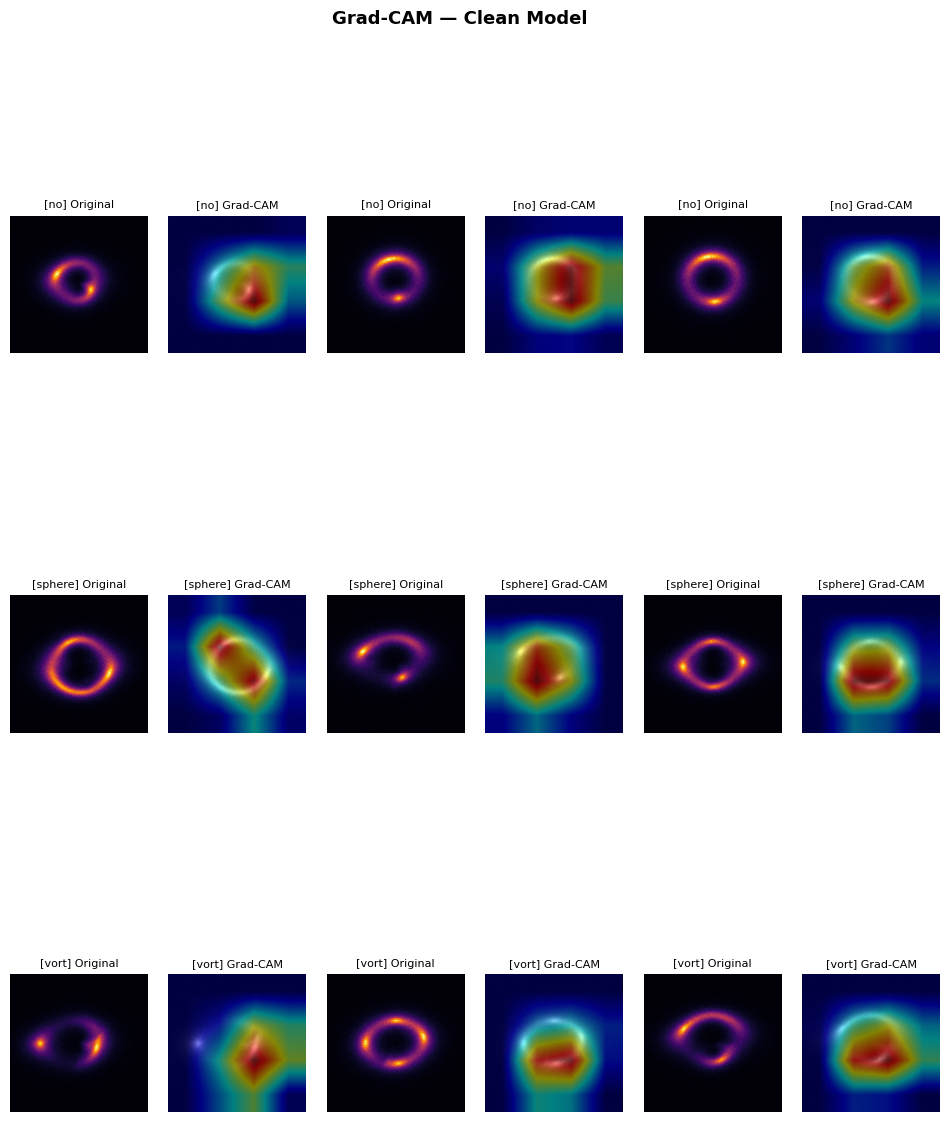

Saved → /content/drive/MyDrive/RobustnessTesting/deeplense_gradcam_Clean_Model.png


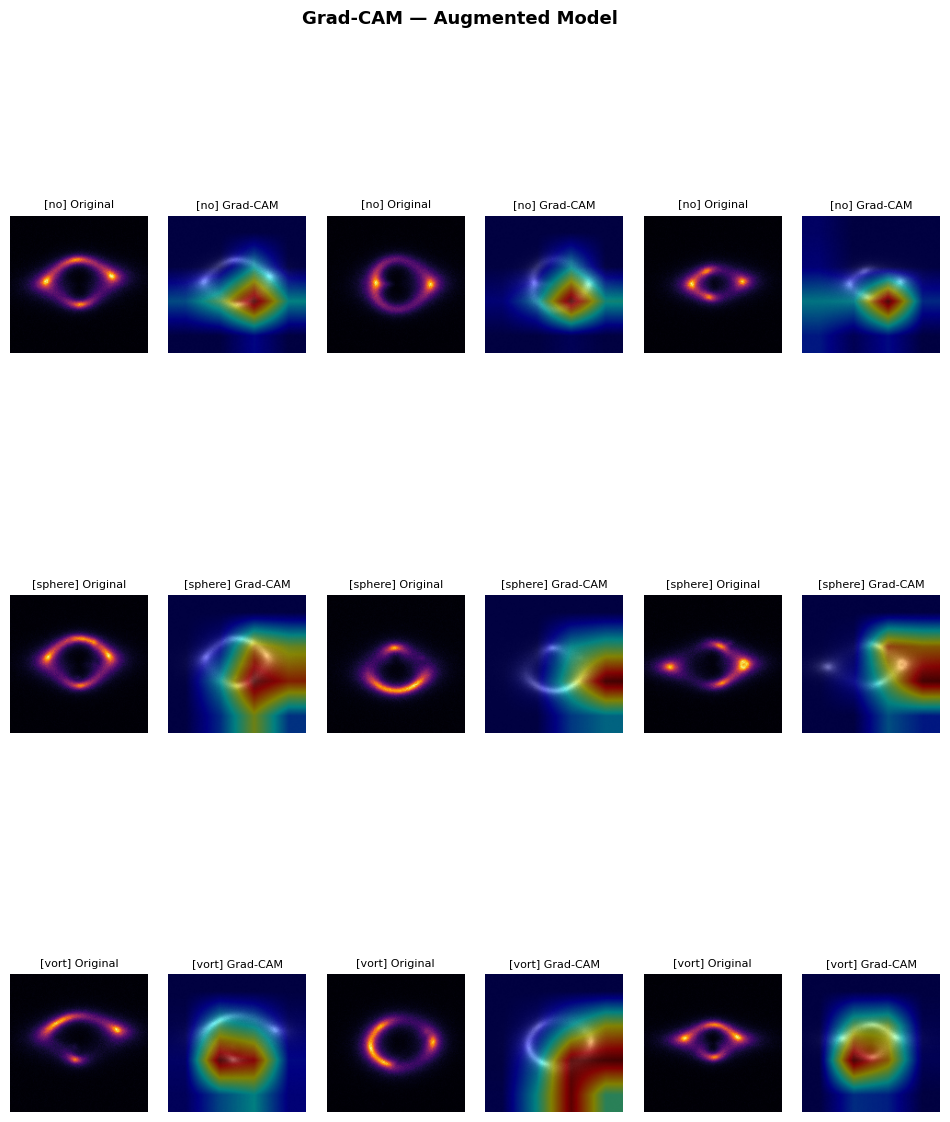

Saved → /content/drive/MyDrive/RobustnessTesting/deeplense_gradcam_Augmented_Model.png


In [29]:
visualize_gradcam(model_clean, 'Clean Model',     n_per_class=3)
visualize_gradcam(model_aug,   'Augmented Model', n_per_class=3)

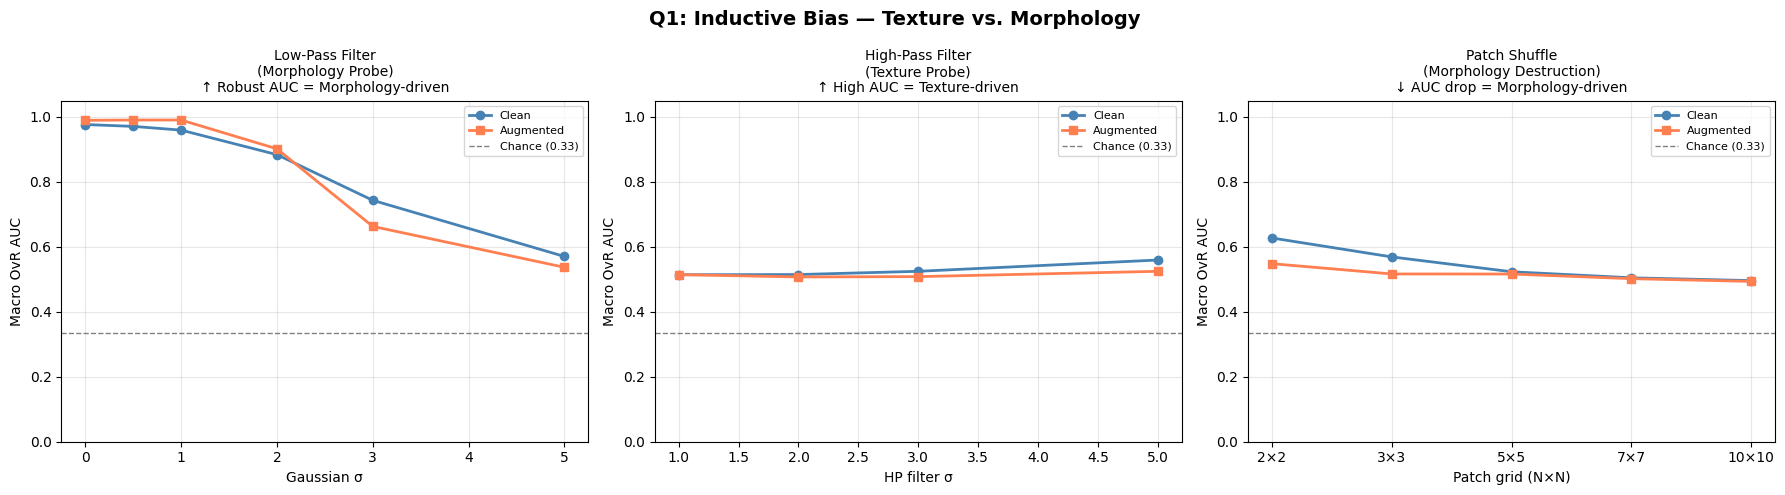

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
chance = 1 / 3

# — Low-pass —
axes[0].plot(LP_SIGMAS, q1_lp_clean, 'o-', color='steelblue', lw=2, label='Clean')
axes[0].plot(LP_SIGMAS, q1_lp_aug,   's-', color='coral',     lw=2, label='Augmented')
axes[0].axhline(chance, color='gray', ls='--', lw=1, label='Chance (0.33)')
axes[0].set_title('Low-Pass Filter\n(Morphology Probe)\n'
                  '↑ Robust AUC = Morphology-driven', fontsize=10)
axes[0].set_xlabel('Gaussian σ'); axes[0].set_ylabel('Macro OvR AUC')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3); axes[0].set_ylim(0, 1.05)

# — High-pass —
axes[1].plot(HP_SIGMAS, q1_hp_clean, 'o-', color='steelblue', lw=2, label='Clean')
axes[1].plot(HP_SIGMAS, q1_hp_aug,   's-', color='coral',     lw=2, label='Augmented')
axes[1].axhline(chance, color='gray', ls='--', lw=1, label='Chance (0.33)')
axes[1].set_title('High-Pass Filter\n(Texture Probe)\n'
                  '↑ High AUC = Texture-driven', fontsize=10)
axes[1].set_xlabel('HP filter σ'); axes[1].set_ylabel('Macro OvR AUC')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3); axes[1].set_ylim(0, 1.05)

# — Patch Shuffle —
patch_labels = [f'{n}×{n}' for n in PATCH_GRIDS]
axes[2].plot(patch_labels, q1_ps_clean, 'o-', color='steelblue', lw=2, label='Clean')
axes[2].plot(patch_labels, q1_ps_aug,   's-', color='coral',     lw=2, label='Augmented')
axes[2].axhline(chance, color='gray', ls='--', lw=1, label='Chance (0.33)')
axes[2].set_title('Patch Shuffle\n(Morphology Destruction)\n'
                  '↓ AUC drop = Morphology-driven', fontsize=10)
axes[2].set_xlabel('Patch grid (N×N)'); axes[2].set_ylabel('Macro OvR AUC')
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3); axes[2].set_ylim(0, 1.05)

plt.suptitle('Q1: Inductive Bias — Texture vs. Morphology', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/RobustnessTesting/deeplense_q1_inductive_bias.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
baseline_auc_clean = q1_lp_clean[0]
print(f"\nBaseline AUC (no corruption): {baseline_auc_clean:.4f}")
lp_drop  = baseline_auc_clean - q1_lp_clean[-1]
hp_score = q1_hp_clean[-1]
ps_drop  = baseline_auc_clean - q1_ps_clean[-1]
print(f"AUC drop under heavy blur (LP σ=5):     {lp_drop:.4f}  → {'small' if lp_drop < 0.05 else 'large'}")
print(f"AUC on high-pass residuals (HP σ=5):    {hp_score:.4f}  → {'above chance' if hp_score > 0.5 else 'near/below chance'}")
print(f"AUC drop after patch shuffle (10×10):   {ps_drop:.4f}  → {'large — morphology-driven' if ps_drop > 0.1 else 'small — texture-driven'}")


Baseline AUC (no corruption): 0.9768
AUC drop under heavy blur (LP σ=5):     0.4064  → large
AUC on high-pass residuals (HP σ=5):    0.5595  → above chance
AUC drop after patch shuffle (10×10):   0.4807  → large — morphology-driven


In [32]:
def make_gauss_noise(sigma):
    def fn(imgs):
        return imgs + np.random.randn(*imgs.shape).astype(np.float32) * sigma
    return fn

In [33]:
def make_gauss_blur(sigma):
    def fn(imgs):
        return gaussian_filter(imgs, sigma=[0, 0, sigma, sigma])
    return fn

In [34]:
def make_rotation_corrupt(angle_deg):
    def fn(imgs):
        return scipy_rotate(imgs, angle=angle_deg, axes=(2, 3), reshape=False)
    return fn

In [35]:
def make_brightness(offset):
    def fn(imgs):
        return imgs + offset
    return fn

In [36]:
def make_center_mask(frac):
    """Mask a central square (fraction of image side) with mid-grey (0.5 in [0,1])."""
    def fn(imgs):
        B, C, H, W = imgs.shape
        h = int(H * frac); w = int(W * frac)
        top  = (H - h) // 2; left = (W - w) // 2
        out  = imgs.copy()
        out[:, :, top:top+h, left:left+w] = 0.5
        return out
    return fn

In [37]:
CORRUPTION_SUITE = {
    'Gaussian Noise':    {
        'levels': [0.00, 0.02, 0.05, 0.10, 0.20],
        'xlabel': 'Noise σ',
        'fns':    [make_gauss_noise(s) for s in [0.00, 0.02, 0.05, 0.10, 0.20]]
    },
    'Gaussian Blur':     {
        'levels': [0.0, 0.5, 1.0, 2.0, 3.0],
        'xlabel': 'Blur σ',
        'fns':    [make_gauss_blur(s) if s > 0 else (lambda x: x)
                   for s in [0.0, 0.5, 1.0, 2.0, 3.0]]
    },
    'Rotation':          {
        'levels': [0, 45, 90, 135, 180],
        'xlabel': 'Angle (°)',
        'fns':    [make_rotation_corrupt(a) if a > 0 else (lambda x: x)
                   for a in [0, 45, 90, 135, 180]]
    },
    'Brightness Shift':  {
        'levels': [-0.20, -0.10, 0.00, 0.10, 0.20],
        'xlabel': 'Offset',
        'fns':    [make_brightness(o) for o in [-0.20, -0.10, 0.00, 0.10, 0.20]]
    },
    'Center Masking':    {
        'levels': [0.0, 0.2, 0.4, 0.6, 0.8],
        'xlabel': 'Masked fraction',
        'fns':    [make_center_mask(f) if f > 0 else (lambda x: x)
                   for f in [0.0, 0.2, 0.4, 0.6, 0.8]]
    },
}

In [38]:
q2_results = {}
for corrupt_name, cfg in CORRUPTION_SUITE.items():
    print(f"\nRunning: {corrupt_name}")
    clean_aucs, aug_aucs = [], []
    for fn in cfg['fns']:
        clean_aucs.append(evaluate_corrupted(model_clean, fn, test_loader))
        aug_aucs.append(evaluate_corrupted(model_aug,   fn, test_loader))
    q2_results[corrupt_name] = {
        'levels': cfg['levels'],
        'xlabel': cfg['xlabel'],
        'clean':  clean_aucs,
        'aug':    aug_aucs,
    }
    print(f"  Clean: {[round(x, 4) for x in clean_aucs]}")
    print(f"  Aug:   {[round(x, 4) for x in aug_aucs]}")


Running: Gaussian Noise
  Clean: [np.float64(0.9768), np.float64(0.6867), np.float64(0.5758), np.float64(0.522), np.float64(0.5035)]
  Aug:   [np.float64(0.9897), np.float64(0.9617), np.float64(0.8165), np.float64(0.6223), np.float64(0.5086)]

Running: Gaussian Blur
  Clean: [np.float64(0.9768), np.float64(0.971), np.float64(0.9595), np.float64(0.884), np.float64(0.7434)]
  Aug:   [np.float64(0.9897), np.float64(0.9906), np.float64(0.9907), np.float64(0.9019), np.float64(0.6631)]

Running: Rotation
  Clean: [np.float64(0.9768), np.float64(0.7468), np.float64(0.7279), np.float64(0.7408), np.float64(0.9761)]
  Aug:   [np.float64(0.9897), np.float64(0.875), np.float64(0.9896), np.float64(0.9184), np.float64(0.9888)]

Running: Brightness Shift
  Clean: [np.float64(0.5962), np.float64(0.7783), np.float64(0.9768), np.float64(0.8381), np.float64(0.7763)]
  Aug:   [np.float64(0.5431), np.float64(0.7149), np.float64(0.9897), np.float64(0.7641), np.float64(0.7251)]

Running: Center Masking
  Cl

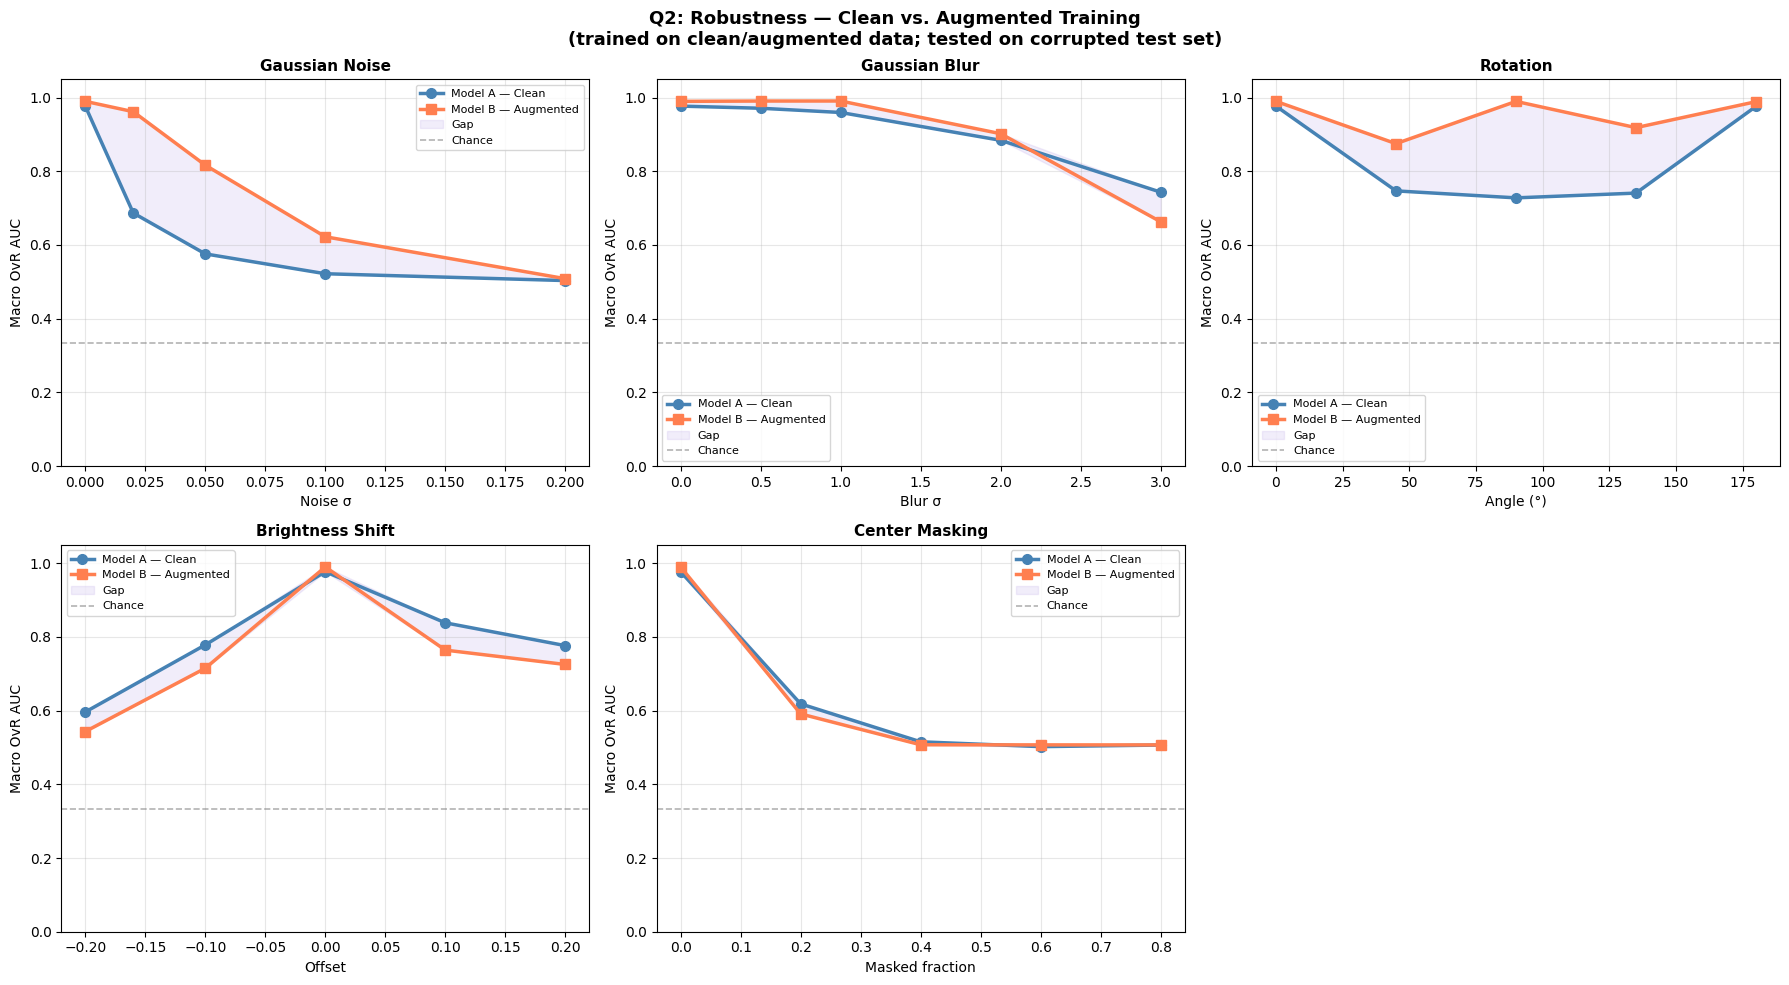

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()
chance    = 1 / 3

for idx, (name, data) in enumerate(q2_results.items()):
    ax = axes_flat[idx]
    levels = data['levels']
    c_vals = data['clean']
    a_vals = data['aug']

    ax.plot(levels, c_vals, 'o-', color='steelblue', lw=2.5, ms=7, label='Model A — Clean')
    ax.plot(levels, a_vals, 's-', color='coral',     lw=2.5, ms=7, label='Model B — Augmented')
    ax.fill_between(
        levels,
        [min(c, a) for c, a in zip(c_vals, a_vals)],
        [max(c, a) for c, a in zip(c_vals, a_vals)],
        alpha=0.12, color='mediumpurple', label='Gap'
    )
    ax.axhline(chance, color='gray', ls='--', lw=1.2, alpha=0.6, label='Chance')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel(data['xlabel']); ax.set_ylabel('Macro OvR AUC')
    ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_ylim(0, 1.05)

axes_flat[-1].axis('off')   # hide empty 6th panel

plt.suptitle('Q2: Robustness — Clean vs. Augmented Training\n'
             '(trained on clean/augmented data; tested on corrupted test set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/RobustnessTesting/deeplense_q2_robustness.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
print("\n" + "=" * 65)
print(f"{'Corruption':<22} | {'Mean AUC Clean':>15} | {'Mean AUC Aug':>12} | Winner")
print("-" * 65)

for name, data in q2_results.items():
    # Skip the zero-corruption baseline point (index 0) when computing mean
    # For brightness shift, no clear zero; just average everything
    vals_c = data['clean'][1:]   # drop clean baseline
    vals_a = data['aug'][1:]
    mean_c = np.mean(vals_c)
    mean_a = np.mean(vals_a)
    winner = "Aug ✓" if mean_a > mean_c else "Clean ✓"
    diff   = abs(mean_a - mean_c)
    print(f"{name:<22} | {mean_c:>15.4f} | {mean_a:>12.4f} | {winner}  (Δ {diff:.4f})")

print("=" * 65)

baseline_c = evaluate(model_clean, test_loader)
baseline_a = evaluate(model_aug,   test_loader)
print(f"\nClean test AUC (no corruption): Clean={baseline_c:.4f} | Aug={baseline_a:.4f}")


Corruption             |  Mean AUC Clean | Mean AUC Aug | Winner
-----------------------------------------------------------------
Gaussian Noise         |          0.5720 |       0.7273 | Aug ✓  (Δ 0.1553)
Gaussian Blur          |          0.8895 |       0.8866 | Clean ✓  (Δ 0.0029)
Rotation               |          0.7979 |       0.9429 | Aug ✓  (Δ 0.1451)
Brightness Shift       |          0.8424 |       0.7984 | Clean ✓  (Δ 0.0439)
Center Masking         |          0.5356 |       0.5280 | Clean ✓  (Δ 0.0076)

Clean test AUC (no corruption): Clean=0.9768 | Aug=0.9897


In [41]:
import json

summary = {
    'baseline_auc': {'clean': baseline_c, 'augmented': baseline_a},
    'q1_lowpass':   {'sigmas': LP_SIGMAS,   'clean': q1_lp_clean, 'aug': q1_lp_aug},
    'q1_highpass':  {'sigmas': HP_SIGMAS,   'clean': q1_hp_clean, 'aug': q1_hp_aug},
    'q1_patchshuffle': {'grids': PATCH_GRIDS, 'clean': q1_ps_clean, 'aug': q1_ps_aug},
    'q2_robustness': {
        name: {'levels': d['levels'], 'clean': d['clean'], 'aug': d['aug']}
        for name, d in q2_results.items()
    }
}

out_json = '/content/drive/MyDrive/RobustnessTesting/deeplense_results.json'
with open(out_json, 'w') as f:
    json.dump(summary, f, indent=2)
print(f"Results saved → {out_json}")

Results saved → /content/drive/MyDrive/RobustnessTesting/deeplense_results.json


In [42]:
print("\n── FINAL SUMMARY ──────────────────────────────────────────")
print(f"Baseline AUC  Clean={baseline_c:.4f}  Aug={baseline_a:.4f}")
print(f"Q1 LP (σ=5)   Clean={q1_lp_clean[-1]:.4f}  Aug={q1_lp_aug[-1]:.4f}")
print(f"Q1 HP (σ=5)   Clean={q1_hp_clean[-1]:.4f}  Aug={q1_hp_aug[-1]:.4f}")
print(f"Q1 PS (10×10) Clean={q1_ps_clean[-1]:.4f}  Aug={q1_ps_aug[-1]:.4f}")
print("────────────────────────────────────────────────────────────")


── FINAL SUMMARY ──────────────────────────────────────────
Baseline AUC  Clean=0.9768  Aug=0.9897
Q1 LP (σ=5)   Clean=0.5704  Aug=0.5371
Q1 HP (σ=5)   Clean=0.5595  Aug=0.5248
Q1 PS (10×10) Clean=0.4961  Aug=0.4937
────────────────────────────────────────────────────────────
